*(**DIGGING INTO BANK NIFTY**)*

In [111]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [112]:
df=pd.read_csv("../data/processed/bank_nifty_daily_amended.csv")
df['date']=pd.to_datetime(df['date'],format="%Y-%m-%d")
df['date'].dtype

dtype('<M8[us]')

Overall Price Trend of BankNifty

In [113]:
df["sma_22"] = df["close"].rolling(window=22).mean()
df["ema_22"] = df["close"].ewm(span=22,adjust=True).mean()

fig = px.line(
    df,
    x="date",
    y=["close", "sma_22", "ema_22"],
    title="Bank Nifty Price Trend — SMA vs EMA"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Bank Nifty",
    legend_title="Series"
)

fig.show()

price_summary = pd.DataFrame({
    "Metric": [
        "Start Date",
        "End Date",
        "Starting Close",
        "Ending Close",
        "Absolute Change",
        "Percentage Change"
    ],
    "Value": [
        df["date"].iloc[0],
        df["date"].iloc[-1],
        df["close"].iloc[0],
        df["close"].iloc[-1],
        df["close"].iloc[-1] - df["close"].iloc[0],
        (
            (df["close"].iloc[-1] / df["close"].iloc[0]) - 1
        ) * 100
    ]
})

price_summary

,Metric,Value
0,Start Date,2023-01-02 00:00:00
1,End Date,2026-08-31 00:00:00
2,Starting Close,43203.1
3,Ending Close,58024.95
4,Absolute Change,14821.85
5,Percentage Change,34.307376


Lets Analyze how much does BankNifty typically move daily and how variable is that movement

In [115]:
df["daily_return"] = df["close"].pct_change() * 100

#visualizing Distribution

fig = px.histogram(
    df,
    x="daily_return",
    nbins=110,
    marginal="box",
    title="Bank Nifty Daily Return Distribution"
)

fig.update_xaxes(
    title="Daily Return"
)

fig.update_yaxes(
    title_text=None
)

fig.show()

daily_return_summary = (
    df["daily_return"]
    .describe(
        percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
    ).to_frame("daily_return")
)

display(daily_return_summary)

largest_moves = (
    df[['date','close','daily_return']]
    .dropna()
    .sort_values('daily_return')
)
print("largest Neative Moves with Dates \n")
display(largest_moves.head(5))
print("largest Positive Moves with Dates \n")
display(largest_moves.tail(5))


df["daily_return_abs"]=df['daily_return'].abs()
print("absolute daily returns \n")
df['daily_return_abs'].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,daily_return
count,907.000000
mean,0.037297
std,0.975930
min,-7.946948
1%,-2.538732
5%,-1.420378
10%,-0.989315
25%,-0.444258
50%,0.045915
75%,0.516542


largest Neative Moves with Dates 



,date,close,daily_return
351,2024-06-04,46928.60,-7.946948
258,2024-01-17,46064.45,-4.281861
803,2026-03-30,50275.35,-3.824515
799,2026-03-23,51437.75,-3.723395
797,2026-03-19,53451.00,-3.389091


largest Positive Moves with Dates 



,date,close,daily_return
582,2025-05-12,55382.85,3.335370
227,2023-12-04,46431.40,3.608678
350,2024-06-03,50979.95,4.074804
352,2024-06-05,49054.60,4.530286
808,2026-04-08,55703.90,5.667418


absolute daily returns 



count    907.000000
mean       0.680728
std        0.699951
min        0.001265
50%        0.475186
75%        0.905851
90%        1.432937
95%        1.998276
99%        3.326609
max        7.946948
Name: daily_return_abs, dtype: float64

Now lets dig into opening gaps, variation and frequency

In [116]:
df["opening_gap"] = (df["open"] / df["close"].shift(1) - 1)
df["opening_gap_pct"] = df["opening_gap"] * 100

gap_summary = (
    df["opening_gap_pct"].describe(percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.99]))
print("gap_summary \n")
display(gap_summary)

print("GAP_VISUALIZATION")
fig = px.histogram(df,x="opening_gap_pct",nbins=129,marginal="box",title="Bank Nifty Opening Gap Distribution")
fig.update_layout(xaxis_title="Opening Gap (%)",yaxis_title="Number of Trading Days")
fig.show()

gap_magnitude = df["opening_gap_pct"].abs()
print("abs_gap \n")
display(gap_magnitude.describe(percentiles=[0.50,0.75,0.90,0.95,0.99]))

print("Largest_pos_gap \n")
display(df.nlargest(10,"opening_gap_pct")[["date", "open", "close", "opening_gap_pct"]])

print("Smallest_neg_gap \n")
display(df.nsmallest(10,"opening_gap_pct")[["date", "open", "close", "opening_gap_pct"]])


gap_summary 



count    907.000000
mean       0.046743
std        0.595141
min       -4.206770
1%        -1.586426
5%        -0.751749
10%       -0.493529
25%       -0.194148
50%        0.064990
75%        0.304379
90%        0.573832
99%        1.513248
max        4.763302
Name: opening_gap_pct, dtype: float64

GAP_VISUALIZATION


abs_gap 



count    907.000000
mean       0.378488
std        0.461485
min        0.000797
50%        0.253123
75%        0.476913
90%        0.788197
95%        1.090630
99%        2.302080
max        4.763302
Name: opening_gap_pct, dtype: float64

Largest_pos_gap 



,date,open,close,opening_gap_pct
766,2026-02-03,61411.20,60041.30,4.763302
808,2026-04-08,54904.45,55703.90,4.150902
350,2024-06-03,50889.85,50979.95,3.890866
565,2025-04-15,52299.00,52379.50,2.542334
804,2026-04-01,51433.90,51448.65,2.304410
582,2025-05-12,54658.75,55382.85,1.984318
227,2023-12-04,45671.50,46431.40,1.913010
800,2026-03-24,52384.80,52605.65,1.841158
469,2024-11-25,52046.35,52207.50,1.781447
853,2026-06-15,57679.65,57198.80,1.522227


Smallest_neg_gap 



,date,open,close,opening_gap_pct
561,2025-04-07,49336.10,49860.10,-4.206770
797,2026-03-19,53474.55,53451.00,-3.346525
258,2024-01-17,46573.95,46064.45,-3.223162
789,2026-03-09,56121.40,56019.80,-2.876006
786,2026-03-04,58447.15,58755.25,-2.327052
811,2026-04-13,54646.00,55605.05,-2.265583
785,2026-03-02,59204.30,59839.65,-2.188538
606,2025-06-13,55149.30,55527.35,-1.664065
805,2026-04-02,50625.65,51548.75,-1.599653
799,2026-03-23,52576.10,51437.75,-1.592733


In [117]:
#How often does Banknifty actually open higher versus lower
gap_direction = pd.Series({
    "Gap Up ": (df["opening_gap_pct"] > 0).mean() * 100,
    "Gap Down  ": (df["opening_gap_pct"] < 0).mean() * 100,
    "No Gap  ": (df["opening_gap_pct"] == 0).mean() * 100
})

gap_direction

Gap Up        57.158590
Gap Down      42.731278
No Gap         0.000000
dtype: float64

Now lets analyze the **IntraDay** movement of banknifty

In [119]:
df["intraday_return_pct"] = ((df["close"] / df["open"] - 1) * 100)
#removed 4th June unusual move
df_normal= df[df["date"] != "2024-06-04"].copy()

intraday_summary = (
    df_normal["intraday_return_pct"]
    .describe(percentiles=[ 0.01,0.05,0.10,0.25,0.50,0.75,0.95,0.99]))
print("\n intraday_summary")
print(intraday_summary)

print("\n Absolute intraday movement: ")
print(df_normal["intraday_return_pct"].abs().describe(percentiles=[0.50,0.75,0.90,0.95,0.99]))

print("\nLargest positive intraday moves:")
print(
    df_normal.nlargest(10, "intraday_return_pct")[
        ["date", "open", "close", "intraday_return_pct"]
    ].to_string(index=False)
)

print("\nLargest negative intraday moves:")
print(
    df_normal.nsmallest(10, "intraday_return_pct")[
        ["date", "open", "close", "intraday_return_pct"]
    ].to_string(index=False)
)

#visualizing

fig = px.violin(df_normal,y="intraday_return_pct",box=True,points=False,title="Bank Nifty Intraday Return Distribution")
fig.update_layout(yaxis_title="Open → Close Return (%)",xaxis_title="")
fig.show()

KeyError: 'intraday_return_pct'

In [120]:
# overnight vs Intraday 

df_normal["overnight_return_pct"] = (
(df_normal["open"] / df_normal["close"].shift(1)) - 1
) * 100

df_normal["intraday_return_pct"] = (
    (df_normal["close"] / df_normal["open"]) - 1
) * 100

movement_components = pd.DataFrame({
    "Overnight": df_normal["overnight_return_pct"].abs(),
    "Intraday": df_normal["intraday_return_pct"].abs()
})

print("Absolute Movement Comparison — Normal Days")
print(
    movement_components.describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nMean absolute movement:")
print(movement_components.mean())

print("\nMedian absolute movement:")
print(movement_components.median())

#visualising
fig = px.box(
    movement_components,
    y=["Overnight", "Intraday"],
    title="Bank Nifty: Overnight vs Intraday Movement — Normal Days"
)

fig.update_layout(
    yaxis_title="Absolute Movement pct",
    xaxis_title="Movement Component"
)

fig.show()

Absolute Movement Comparison — Normal Days
        Overnight    Intraday
count  906.000000  907.000000
mean     0.384479    0.556703
std      0.508618    0.495746
min      0.000797    0.000115
50%      0.252211    0.417307
75%      0.475905    0.799542
90%      0.788776    1.232636
95%      1.091253    1.531036
99%      2.325920    2.163521
max      6.852400    3.301984

Mean absolute movement:
Overnight    0.384479
Intraday     0.556703
dtype: float64

Median absolute movement:
Overnight    0.252211
Intraday     0.417307
dtype: float64


In [121]:
# Intraday price range in Bank Nifty points
df_normal["intraday_range"] = (
    df_normal["high"] - df_normal["low"]
)

# Intraday range normalized by opening price
df_normal["intraday_range_pct"] = (
    df_normal["intraday_range"] / df_normal["open"]
) * 100

print("Intraday Range — Normal Days")

print(
    df_normal[
        ["intraday_range", "intraday_range_pct"]
    ].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nLargest Intraday Ranges:")

print(
    df_normal.nlargest(10, "intraday_range")[
        [
            "date",
            "open",
            "high",
            "low",
            "close",
            "intraday_range",
            "intraday_range_pct"
        ]
    ].to_string(index=False)
)

# Visualisation

fig = px.histogram(
    df_normal,
    x="intraday_range_pct",
    nbins=60,
    title="Bank Nifty Intraday Range Distribution - Normal Days"
)

fig.update_layout(
    xaxis_title="High-Low Range (Pct of Open)",
    yaxis_title="Number of Trading Days"
)

fig.show()

Intraday Range — Normal Days
       intraday_range  intraday_range_pct
count      907.000000          907.000000
mean       585.733848            1.161797
std        293.961394            0.591496
min        114.200000            0.236943
25%        386.525000            0.766703
50%        517.850000            1.033441
75%        717.350000            1.430476
90%        961.580000            1.917248
95%       1123.470000            2.240504
99%       1519.010000            3.066443
max       2916.100000            6.141676

Largest Intraday Ranges:
      date     open     high      low    close  intraday_range  intraday_range_pct
2024-06-05 47486.60 49362.90 46446.80 49054.60         2916.10            6.140890
2023-02-01 41115.00 42015.65 39490.50 40513.00         2525.15            6.141676
2026-02-01 59607.65 59865.70 57783.20 58417.20         2082.50            3.493679
2026-02-03 61411.20 61764.85 59793.20 60041.30         1971.65            3.210571
2026-04-02 50625.65 51731.

In [122]:
# Directional move from its open— normal days

df_normal["upward_move_pct"] = (
    (df_normal["high"] - df_normal["open"])
    / df_normal["open"]
) * 100

df_normal["downward_move_pct"] = (
    (df_normal["open"] - df_normal["low"])
    / df_normal["open"]
) * 100

mov_summary = df_normal[
    ["upward_move_pct", "downward_move_pct"]
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

print(mov_summary)

fig = px.box(
    df_normal[
        ["upward_move_pct", "downward_move_pct"]
    ],
    y=[
        "upward_move_pct",
        "downward_move_pct"
    ],
    title="Bank Nifty Directional Intraday Movement — Normal Days"
)

fig.update_layout(
    yaxis_title="Movement from Open %",
    xaxis_title="Direction"
)

fig.show()

       upward_move_pct  downward_move_pct
count       907.000000         907.000000
mean          0.562467           0.599330
std           0.494287           0.521213
min           0.000000           0.000000
25%           0.207534           0.240566
50%           0.434446           0.465620
75%           0.778393           0.824024
90%           1.207354           1.280432
95%           1.537795           1.563396
99%           2.208495           2.381131
max           3.951220           3.951113


In [125]:
# Comparing posititve v/s negative closing movemement range


up_days = df_normal[df_normal["close"] > df_normal["open"]].copy()
down_days = df_normal[df_normal["close"] < df_normal["open"]].copy()

up_days["range_pct"] = (
    (up_days["high"] - up_days["low"]) / up_days["open"]
) * 100

down_days["range_pct"] = (
    (down_days["high"] - down_days["low"]) / down_days["open"]
) * 100

range_comparison = pd.DataFrame({
    "Up Days": up_days["range_pct"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Down Days": down_days["range_pct"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
})

print(range_comparison)

print("\nNumber of days:")
print("Up days:", len(up_days))
print("Down days:", len(down_days))

fig = px.box(
    pd.DataFrame({
        "Up Days": up_days["range_pct"],
        "Down Days": down_days["range_pct"]
    }),
    y=["Up Days", "Down Days"],
    title="Intraday Range: Up Days vs Down Days"
)

fig.update_layout(
    yaxis_title="High-Low Range (% of Open)",
    xaxis_title="Day Type"
)

fig.show()

          Up Days   Down Days
count  440.000000  467.000000
mean     1.171414    1.152735
std      0.583355    0.599549
min      0.236943    0.312804
25%      0.777945    0.759220
50%      1.048743    1.030362
75%      1.424897    1.430476
90%      1.929630    1.895358
95%      2.241776    2.235981
99%      2.961104    3.073225
max      6.140890    6.141676

Number of days:
Up days: 440
Down days: 467


Lets get into Volatility of Bank Nifty Now


Baseline Volatility
Daily volatility: 0.9396675172909399

Rolling Volatility
count    885.000000
mean       0.899062
std        0.392458
min        0.375378
25%        0.621753
50%        0.807148
75%        1.041710
90%        1.254509
95%        1.748038
99%        2.305549
max        2.501703
Name: rolling_vol_22d, dtype: float64

Volatility clustering
Lag-1 autocorrelation : 0.1583
Lag-5 autocorrelation : 0.0868
Lag-22 autocorrelation: 0.0129

Volatility Rgimes
                   days  mean_return  volatility  median_abs_return  \
volatility_regime                                                     
Low                 222     0.063521    0.565910           0.400809   
Normal              442     0.021952    0.808563           0.456797   
High                221     0.109840    1.370766           0.749445   

                   max_abs_return  
volatility_regime                  
Low                      1.562181  
Normal                   3.608678  
High                     5.66

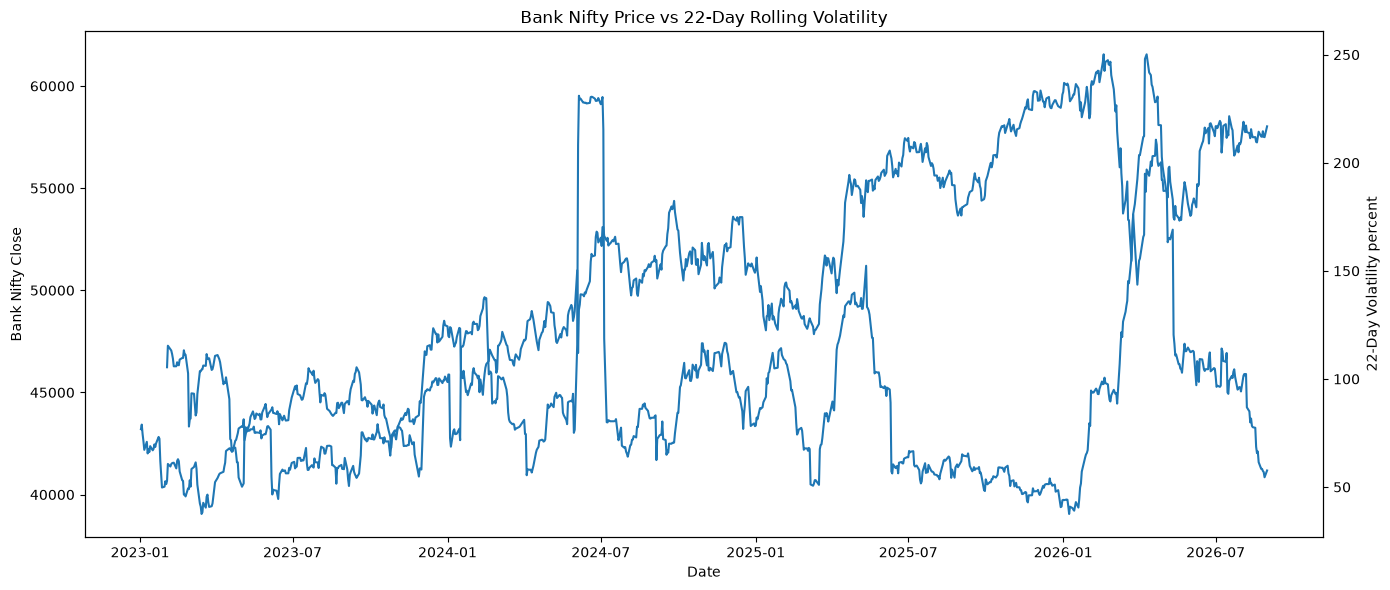

In [138]:
#baseline volatility
daily_volatility = df_normal["daily_return"].std()

print("\nBaseline Volatility")
print(f"Daily volatility: {daily_volatility}")

#rolling volatiliy
df["rolling_vol_22d"] = (
    df["daily_return"]
    .rolling(window=22)
    .std()
)

df_normal["rolling_vol_22d"] = (
    df["daily_return"]
    .rolling(window=22)
    .std()
)

print("\nRolling Volatility")
print(
    df_normal["rolling_vol_22d"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

# volatility clustering using autocorrelation of absolute returns.

abs_returns = df_normal["daily_return"].abs()

vol_clustering_lag1 = abs_returns.autocorr(lag=1)
vol_clustering_lag5 = abs_returns.autocorr(lag=5)
vol_clustering_lag22 = abs_returns.autocorr(lag=22)

print("\nVolatility clustering")
print(f"Lag-1 autocorrelation : {vol_clustering_lag1:.4f}")
print(f"Lag-5 autocorrelation : {vol_clustering_lag5:.4f}")
print(f"Lag-22 autocorrelation: {vol_clustering_lag22:.4f}")

#define volatility regimes using emperical distribution of rolling volatility
q25 = df_normal["rolling_vol_22d"].quantile(0.25)
q75 = df_normal["rolling_vol_22d"].quantile(0.75)

df_normal["volatility_regime"] = pd.cut(
    df_normal["rolling_vol_22d"],
    bins=[-np.inf, q25, q75, np.inf],
    labels=["Low", "Normal", "High"]
)

regime_summary = (
    df_normal
    .groupby("volatility_regime", observed=False)["daily_return"]
    .agg(
        days="count",
        mean_return="mean",
        volatility="std",
        median_abs_return=lambda x: x.abs().median(),
        max_abs_return=lambda x: x.abs().max()
    )
)

print("\nVolatility Rgimes")
print(regime_summary)

# range of a regime
regime_share = (
    df_normal["volatility_regime"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nRegime distribution")
print(regime_share)

#Visualisation
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(
    df["date"],
    df["close"],
    label="Bank Nifty Close"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Bank Nifty Close")
ax2 = ax1.twinx()
ax2.plot(
    df["date"],
    df["rolling_vol_22d"] * 100,
    label="22-Day Rolling Volatility"
)
ax2.set_ylabel("22-Day Volatility percent")
plt.title("Bank Nifty Price vs 22-Day Rolling Volatility")
plt.tight_layout()
plt.show()

Lets do some seasonality analysis and find out how banknifty behaves in different months

In [143]:
df_normal["month"] = df_normal["date"].dt.month
df_normal["month_name"] = df_normal["date"].dt.month_name()

monthly = (
    df_normal
    .groupby(["month", "month_name"])["daily_return"]
    .agg(
        observations="count",
        mean_return="mean",
        median_return="median",
        volatility="std",
        mean_absolute_return=lambda x: x.abs().mean()
    )
    .reset_index()
)

monthly = monthly.sort_values("month")

print("\nMonthly Seasonality")
print(
    monthly[
        [
            "month_name",
            "observations",
            "mean_return",
            "median_return",
            "volatility",
            "mean_absolute_return"
        ]
    ].to_string(index=False)
)

#Monthly range of observe behaviour
print("\nMonthly Differences")

print(
    f"Highest average return month: "
    f"{monthly.loc[monthly['mean_return'].idxmax(), 'month_name']} "
    f"({monthly['mean_return'].max():.3f}%)"
)

print(
    f"Lowest average return month: "
    f"{monthly.loc[monthly['mean_return'].idxmin(), 'month_name']} "
    f"({monthly['mean_return'].min():.3f}%)"
)

print(
    f"Highest volatility month: "
    f"{monthly.loc[monthly['volatility'].idxmax(), 'month_name']} "
    f"({monthly['volatility'].max():.3f}%)"
)

print(
    f"Lowest volatility month: "
    f"{monthly.loc[monthly['volatility'].idxmin(), 'month_name']} "
    f"({monthly['volatility'].min():.3f}%)"
)


Monthly Seasonality
month_name  observations  mean_return  median_return  volatility  mean_absolute_return
   January            85    -0.152380      -0.027125    1.056040              0.792922
  February            82    -0.017303      -0.007845    0.822959              0.603140
     March            78    -0.107602       0.015110    1.363961              1.013466
     April            76     0.354058       0.290193    1.215809              0.889189
       May            84     0.019066       0.003432    0.909725              0.655565
      June            81     0.313711       0.205693    0.993640              0.683073
      July            89    -0.024401      -0.074664    0.701158              0.539222
    August            83    -0.082007      -0.091818    0.666089              0.495177
 September            63     0.102042       0.199088    0.697902              0.552924
   October            63    -0.016412      -0.027440    0.865034              0.695183
  November            

-------------------------------------------------------------

**(*UNDERSTANDING COMPONENTS*)**

In [150]:
df = pd.read_csv("../data/processed/constituent_stocks_data.csv")
df['date']=pd.to_datetime(df['date'])

In [159]:
#creating variables required for analysing the movement of stocks
df = df.sort_values(["symbol", "date"]).copy()

df["daily_return_pct"] = (
    df.groupby("symbol")["close"]
      .pct_change() * 100
)

df["abs_daily_return_pct"] = df["daily_return_pct"].abs()

df["intraday_range_pct"] = (
    (df["high"] - df["low"]) / df["open"]
) * 100


# Constituent-level movement profile

constituent_profile = (
    df.groupby("symbol")
      .agg(
          observations=("date", "count"),

          mean_daily_return_pct=(
              "daily_return_pct", "mean"
          ),

          median_daily_return_pct=(
              "daily_return_pct", "median"
          ),

          daily_volatility_pct=(
              "daily_return_pct", "std"
          ),

          median_abs_daily_return_pct=(
              "abs_daily_return_pct", "median"
          ),

          p95_abs_daily_return_pct=(
              "abs_daily_return_pct",
              lambda x: x.quantile(0.95)
          ),

          median_intraday_range_pct=(
              "intraday_range_pct", "median"
          ),

          p95_intraday_range_pct=(
              "intraday_range_pct",
              lambda x: x.quantile(0.95)
          )
      )
      .sort_values(
          "daily_volatility_pct",
          ascending=False
      )
      .round(3)
)

print("\nConstituent Movement Profile")
display(constituent_profile)

# Rank constituents by normal movement
movement_ranking = (
    constituent_profile[
        [
            "daily_volatility_pct",
            "median_abs_daily_return_pct",
            "p95_abs_daily_return_pct",
            "median_intraday_range_pct"
        ]
    ]
    .sort_values(
        "median_abs_daily_return_pct",
        ascending=False
    )
)

print("\nMovement Ranking")
display(movement_ranking)


Constituent Movement Profile


,observations,mean_daily_return_pct,median_daily_return_pct,daily_volatility_pct,median_abs_daily_return_pct,p95_abs_daily_return_pct,median_intraday_range_pct,p95_intraday_range_pct
symbol,,,,,,,,
BANDHANBNK,902,-0.012,-0.027,2.331,1.228,4.423,2.603,5.454
UNIONBANK,902,0.133,0.098,2.263,1.238,4.531,2.748,5.904
YESBANK,902,0.031,-0.050,2.239,0.983,4.657,2.381,6.474
INDUSINDBK,902,0.004,0.066,2.061,0.974,3.519,2.173,4.881
PNB,902,0.106,0.095,2.020,1.043,4.030,2.368,5.285
CANBK,902,0.105,0.069,1.974,1.027,4.039,2.404,5.044
BANKBARODA,902,0.060,0.057,1.940,0.993,3.645,2.310,4.715
AUBANK,902,0.075,0.061,1.926,0.967,3.694,2.331,5.093
IDFCFIRSTB,902,0.055,0.025,1.796,0.937,3.418,2.123,4.739



Movement Ranking


,daily_volatility_pct,median_abs_daily_return_pct,p95_abs_daily_return_pct,median_intraday_range_pct
symbol,,,,
UNIONBANK,2.263,1.238,4.531,2.748
BANDHANBNK,2.331,1.228,4.423,2.603
PNB,2.020,1.043,4.030,2.368
CANBK,1.974,1.027,4.039,2.404
BANKBARODA,1.940,0.993,3.645,2.310
YESBANK,2.239,0.983,4.657,2.381
INDUSINDBK,2.061,0.974,3.519,2.173
AUBANK,1.926,0.967,3.694,2.331
IDFCFIRSTB,1.796,0.937,3.418,2.123


In [160]:
# visualisation
plot_df = (
    constituent_profile
    .sort_values("median_abs_daily_return_pct")
    .reset_index()
)

fig = px.bar(
    plot_df,
    x="median_abs_daily_return_pct",
    y="symbol",
    orientation="h",
    title="Typical Daily Movement of Bank Nifty Constituents",
    labels={
        "median_abs_daily_return_pct":
            "Median Absolute Daily Movement %",
        "symbol": "Constituent"
    }
)

fig.show()


In [161]:
# Key summary

highest_volatility = (
    constituent_profile["daily_volatility_pct"]
    .idxmax()
)

lowest_volatility = (
    constituent_profile["daily_volatility_pct"]
    .idxmin()
)

highest_typical_move = (
    constituent_profile["median_abs_daily_return_pct"]
    .idxmax()
)

lowest_typical_move = (
    constituent_profile["median_abs_daily_return_pct"]
    .idxmin()
)

print("\nKey Findings")

print(
    f"Highest daily volatility: {highest_volatility} "
    f"({constituent_profile.loc[highest_volatility, 'daily_volatility_pct']:.3f}%)"
)

print(
    f"Lowest daily volatility: {lowest_volatility} "
    f"({constituent_profile.loc[lowest_volatility, 'daily_volatility_pct']:.3f}%)"
)

print(
    f"Largest typical daily movement: {highest_typical_move} "
    f"({constituent_profile.loc[highest_typical_move, 'median_abs_daily_return_pct']:.3f}%)"
)

print(
    f"Smallest typical daily movement: {lowest_typical_move} "
    f"({constituent_profile.loc[lowest_typical_move, 'median_abs_daily_return_pct']:.3f}%)"
)


Key Findings
Highest daily volatility: BANDHANBNK (2.331%)
Lowest daily volatility: ICICIBANK (1.161%)
Largest typical daily movement: UNIONBANK (1.238%)
Smallest typical daily movement: ICICIBANK (0.601%)
